<a href="https://colab.research.google.com/github/SRChandra/Capstoneproject_PID_TEAM2/blob/feature%2Fcapstone_team2_final/Pima_Diabetes_ML_Capstone_Project_%E2%80%94_Team_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning–Based Clinical Decision Support for Early Diabetes Risk in Women (Pima Dataset)

**AIH Capstone Project 1 — Team 2**  
**Dataset:** National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK).  
**Cohort constraint:** Female patients ≥21 years, Pima Indian heritage.  
**Records:** 768; **Features (8):** Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age; **Target:** Outcome (0/1).

> **Abstract**\
This notebook builds an end‑to‑end, reproducible ML pipeline to predict diabetes status (binary `Outcome`) from eight routinely collected predictors in the Pima Indians cohort. We address implausible zero entries via median imputation (performed *inside* the ML pipeline to prevent data leakage), explore class imbalance with **SMOTE**, perform **univariate analysis** (violin, box, KDE), apply **feature selection**, run **repeated stratified k‑fold cross‑validation** (mean & std), and deliver a **clean, reproducible pipeline** with clear comments. **This is a methodological demonstration and not a clinical diagnostic tool.**

---

## 1) Problem Statement
Build and evaluate machine‑learning models that classify whether a female patient (≥21 years, Pima Indian heritage) is likely to have diabetes (`Outcome`=1) using eight routinely available features. Compare baseline models, models with data balancing (SMOTE) and scaling, and models trained on **important features only**, reporting both cross‑validated and hold‑out test performance.

> **Disclaimer:** This notebook is for educational demonstration only and **must not** be used for clinical diagnosis or patient care decisions.


In [9]:
# 2) Setup & Imports
import sys, warnings, io
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, balanced_accuracy_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay, classification_report
)
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Optional XGBoost
try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# SMOTE & Imblearn Pipeline (fallback if not installed)
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    HAS_IMB = True
except Exception:
    HAS_IMB = False

import joblib

RANDOM_STATE = 42
print('Python:', sys.version.split()[0])
print('numpy:', np.__version__)
print('pandas:', pd.__version__)
print('seaborn:', sns.__version__)
print('xgboost:', 'yes' if HAS_XGB else 'no')
print('imblearn:', 'yes' if HAS_IMB else 'no')


Python: 3.12.12
numpy: 2.0.2
pandas: 2.2.2
seaborn: 0.13.2
xgboost: yes
imblearn: yes


## 2) Data Loading
Looks for a local `diabetes.csv`. If not found, attempts a download from public mirrors. Assigns standard column names if required.


In [10]:
LOCAL_PATHS = [Path('./diabetes.csv'), Path('./data/diabetes.csv')]
PUBLIC_URLS = [
    'https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv',
    'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv',
]

COLUMNS = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

import urllib.request

def load_data():
    # local
    for p in LOCAL_PATHS:
        if p.exists():
            df = pd.read_csv(p)
            if df.shape[1] == 9:
                df.columns = COLUMNS
            return df, str(p)
    # try download (requires internet when executed)
    for url in PUBLIC_URLS:
        try:
            with urllib.request.urlopen(url, timeout=20) as r:
                data = r.read()
            df = pd.read_csv(io.BytesIO(data), header=0)
            if df.shape[1] == 9 and set(df.columns) != set(COLUMNS):
                df.columns = COLUMNS
            return df, url
        except Exception:
            continue
    raise FileNotFoundError('Place diabetes.csv next to the notebook and re-run.')

pima_data, data_source = load_data()
print('Loaded shape:', pima_data.shape)
print('Data source:', data_source)
pima_data.head()


Loaded shape: (768, 9)
Data source: https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3) Data Audit & EDA
Schema, stats, and implausible zeros (treated as missing in physiologic fields). We also plot boxplots, violin plots, KDE, and a correlation heatmap.


INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
Describe:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Zero counts (often indicate missing):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


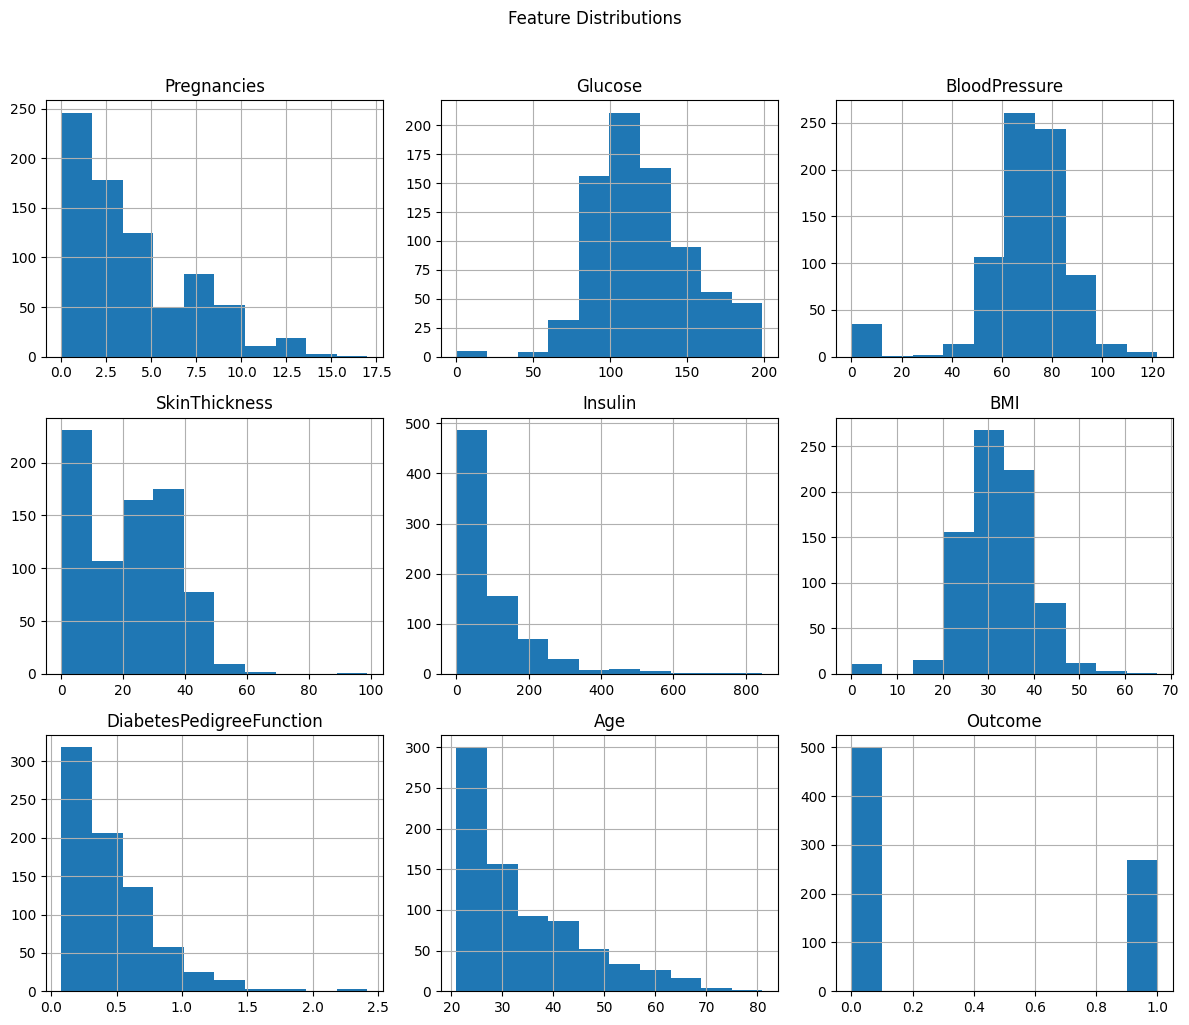

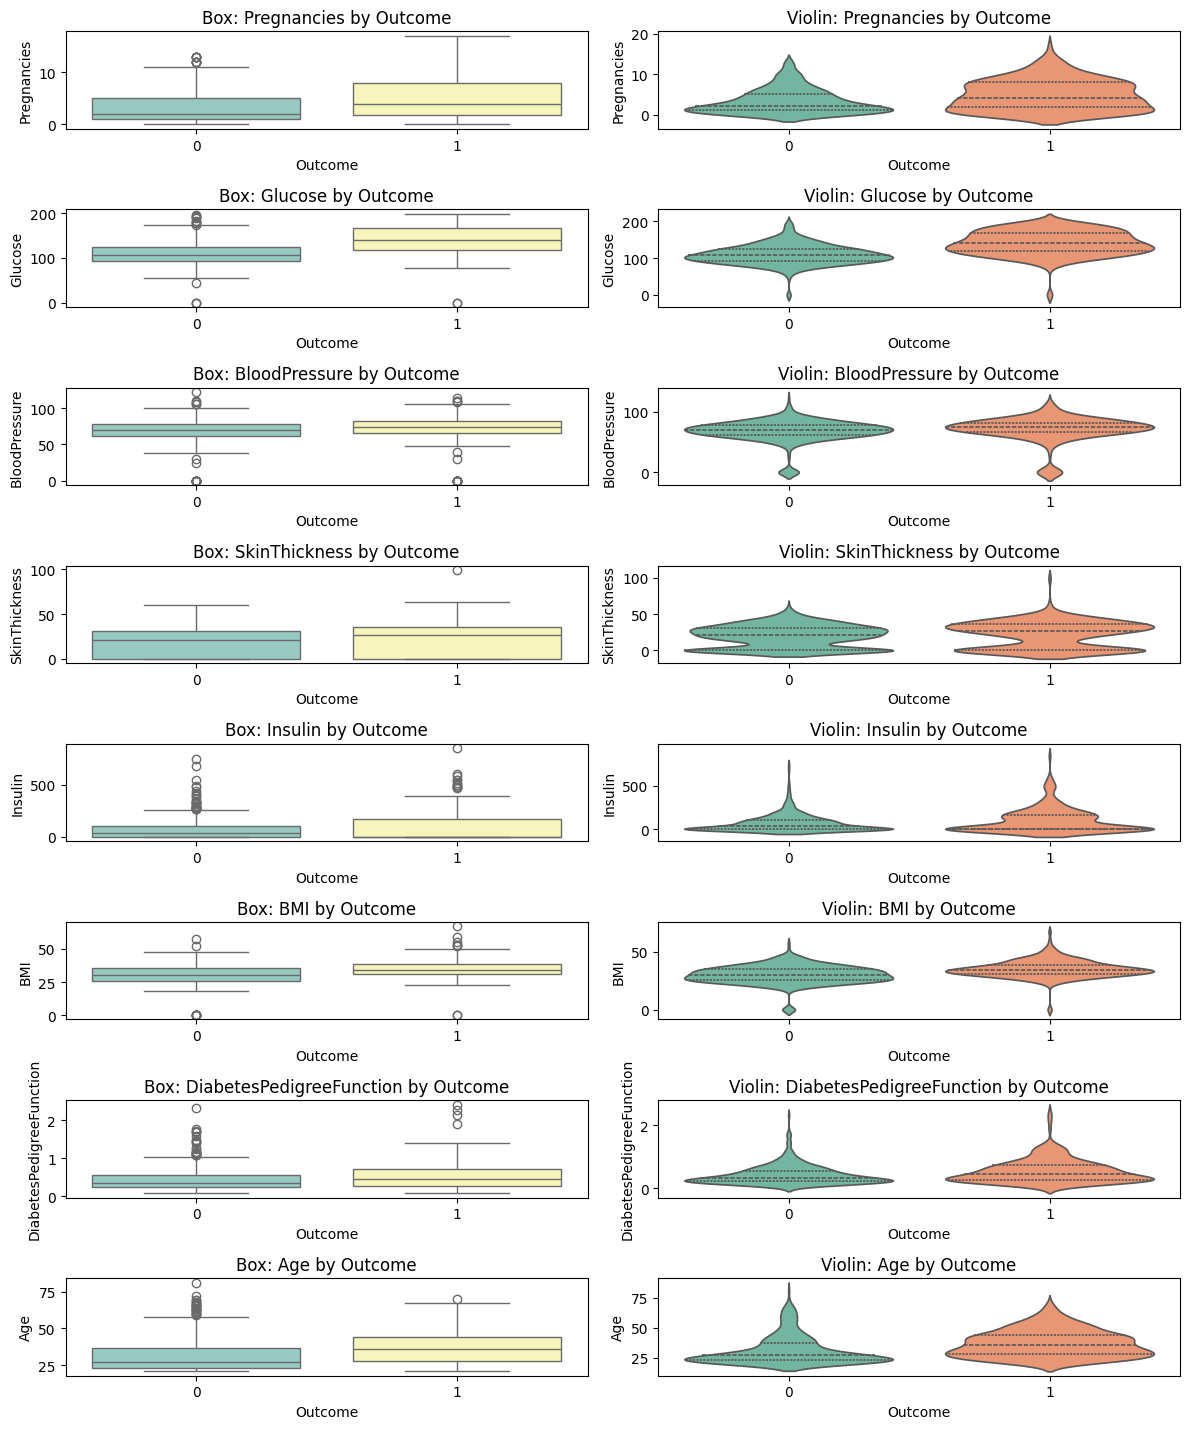

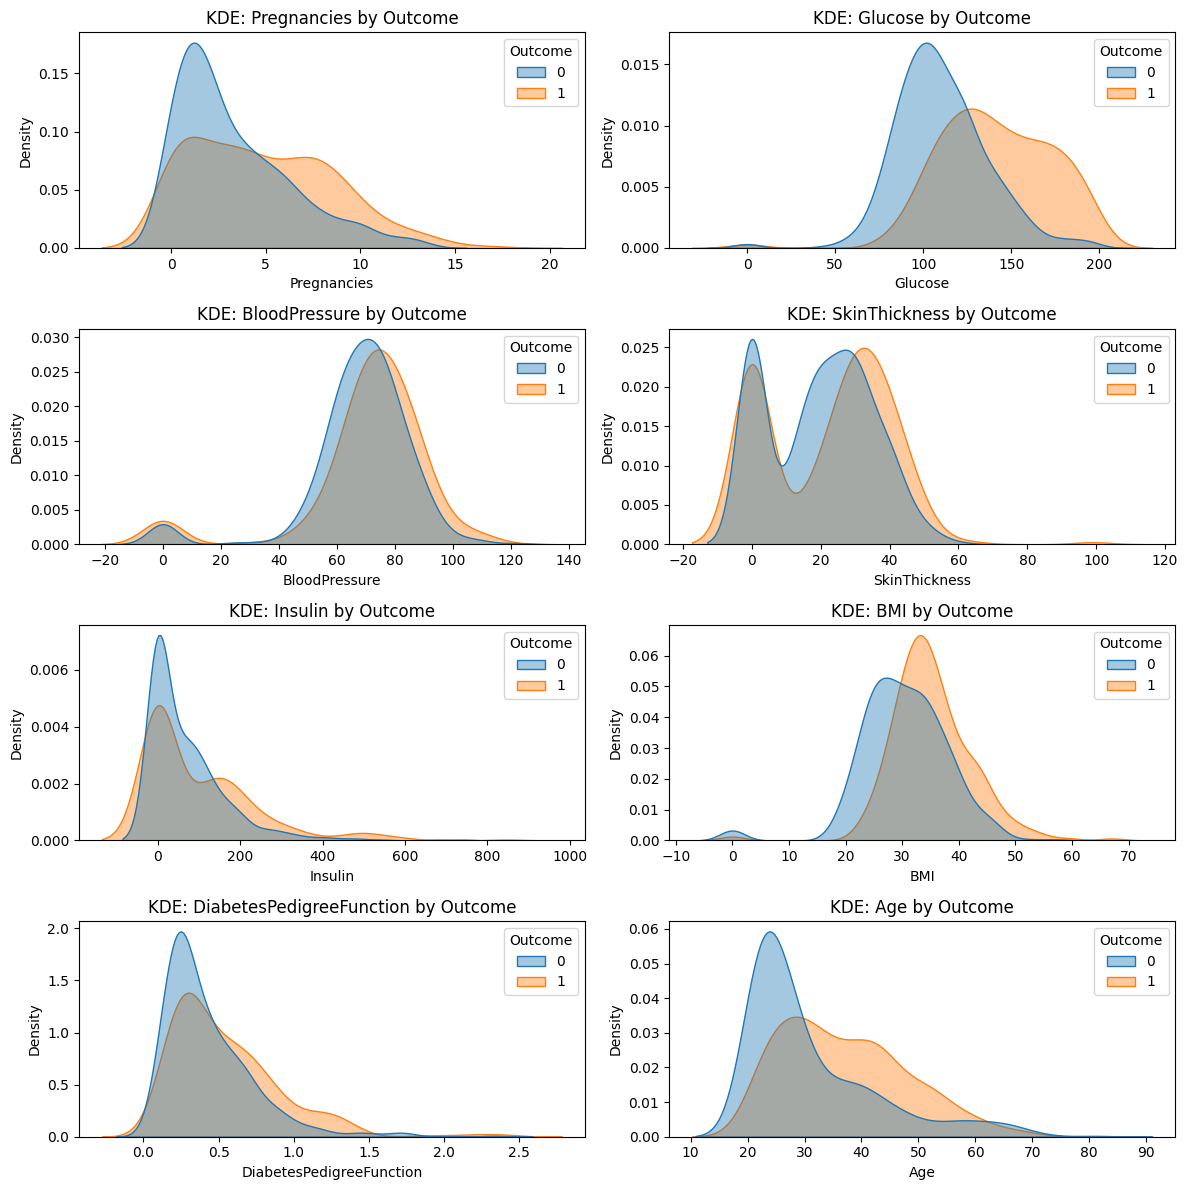

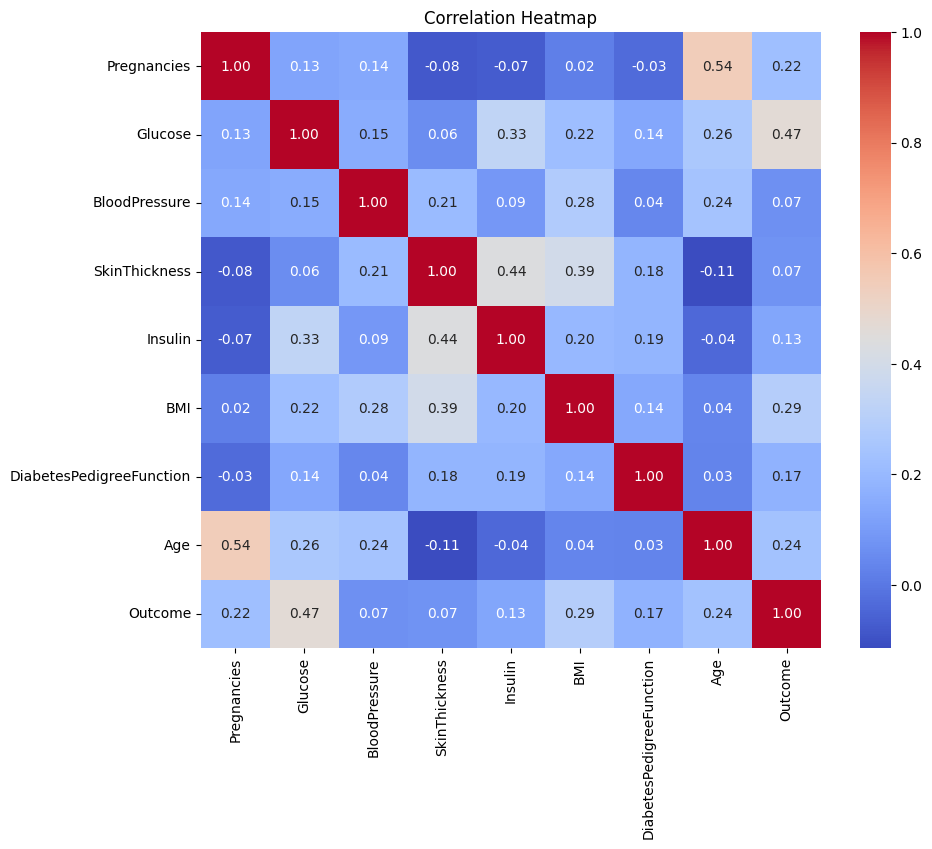

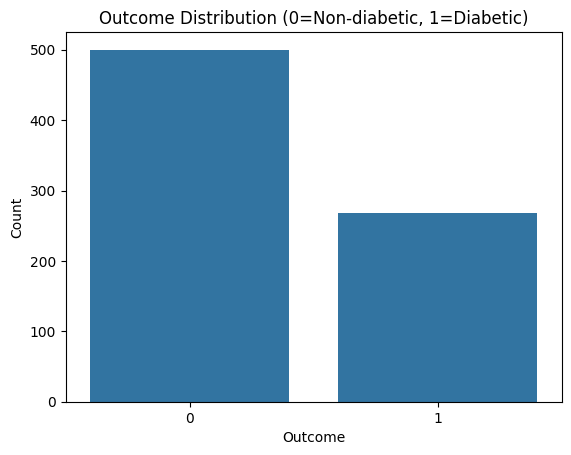

Outcome
0    500
1    268
Name: count, dtype: int64


In [11]:
print('INFO:')
print(pima_data.info())

print('Describe:')
display(pima_data.describe(include='all'))

zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
print('Zero counts (often indicate missing):')
print((pima_data[zero_cols] == 0).sum())

# Histograms
_ = pima_data.hist(figsize=(12,10))
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout(); plt.show()

# Box & Violin plots vs Outcome
features = [c for c in pima_data.columns if c != 'Outcome']
ncols = 2
nrows = int(np.ceil(len(features)))
plt.figure(figsize=(12, max(6, int(len(features))*1.8)))
for i, col in enumerate(features):
    plt.subplot(nrows, ncols, 2*i+1)
    sns.boxplot(x=pima_data['Outcome'], y=pima_data[col], palette='Set3')
    plt.title(f'Box: {col} by Outcome')
    plt.xlabel('Outcome'); plt.ylabel(col)

    plt.subplot(nrows, ncols, 2*i+2)
    sns.violinplot(x=pima_data['Outcome'], y=pima_data[col], palette='Set2', inner='quartile')
    plt.title(f'Violin: {col} by Outcome')
    plt.xlabel('Outcome'); plt.ylabel(col)
plt.tight_layout(); plt.show()

# KDE overlays
plt.figure(figsize=(12, int(np.ceil(len(features)/2))*3))
for i, col in enumerate(features, 1):
    plt.subplot(int(np.ceil(len(features)/2)), 2, i)
    try:
        sns.kdeplot(data=pima_data, x=col, hue='Outcome', fill=True, common_norm=False, alpha=0.4)
        plt.title(f'KDE: {col} by Outcome')
    except Exception:
        plt.title(f'KDE: {col} (skipped)')
plt.tight_layout(); plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(pima_data.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Outcome distribution
sns.countplot(x=pima_data['Outcome'])
plt.title('Outcome Distribution (0=Non-diabetic, 1=Diabetic)')
plt.xlabel('Outcome'); plt.ylabel('Count')
plt.show()
print(pima_data['Outcome'].value_counts())


## 4) Methodology
**Preprocessing**: Treat physiologically implausible zeros as missing for `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`; then **impute medians**. To avoid **data leakage**, zero→NaN and imputation are performed **inside the pipeline**. Scaling (`StandardScaler`) is applied in the *balanced/scaled* scenario.

**Data balancing**: **SMOTE** is applied within cross‑validation folds (no leakage).

**Models**: Logistic Regression (LR), Random Forest (RF), Gradient Boosting (GBDT), Support Vector Machine (SVM, RBF), K‑Nearest Neighbors (KNN), and optionally XGBoost.

**Feature importance**: Prefer model‑based importance (RF `feature_importances_`, LR `coef_`); fallback to permutation importance on a validation split. Retrain models on **Top‑k features** and re‑evaluate.

**Validation**: **RepeatedStratifiedKFold** (5 folds × 3 repeats). Metrics: Accuracy, Balanced Accuracy, Precision, Recall, F1, ROC‑AUC.


In [12]:
# 5) Pipelines & Utilities
cols_missing_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
num_features = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']

def zero_to_nan(df):
    df = df.copy()
    # Filter cols_missing_zero to only include columns present in the current DataFrame
    current_cols_to_process = [col for col in cols_missing_zero if col in df.columns]
    if current_cols_to_process:
        df[current_cols_to_process] = df[current_cols_to_process].replace(0, np.nan)
    return df

zero_to_nan_tf = FunctionTransformer(zero_to_nan, feature_names_out='one-to-one')

# Baseline preprocess: zero->NaN + median impute (no scaling)
preprocess_base = Pipeline(steps=[('zero_to_nan', zero_to_nan_tf), ('impute', SimpleImputer(strategy='median'))])
pre_ct_base = ColumnTransformer([('num', preprocess_base, num_features)], remainder='drop')

# Full preprocess: zero->NaN + impute + scale (for balanced/scaled scenario)
preprocess_full = Pipeline(steps=[('zero_to_nan', zero_to_nan_tf), ('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())])
pre_ct_full = ColumnTransformer([('num', preprocess_full, num_features)], remainder='drop')

# Train/test split
X = pima_data.drop(columns=['Outcome']).copy()
y = pima_data['Outcome'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# CV setup
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

from sklearn.metrics import make_scorer
scorers = {
    'accuracy': make_scorer(accuracy_score),
    'balanced_accuracy': make_scorer(balanced_accuracy_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'roc_auc': 'roc_auc'
}

def cv_table(model, X, y, cv):
    rows = []
    for name, scorer in scorers.items():
        scores = cross_val_score(model, X, y, cv=cv, scoring=scorer)
        rows.append({'metric': name, 'mean': float(scores.mean()), 'std': float(scores.std())})
    return pd.DataFrame(rows).set_index('metric')

def evaluate_pipeline(group, name, pipe, results_list, cv_scores_list):
    # CV on training data
    table = cv_table(pipe, X, y, cv)
    cv_scores_list.append(
        {
            'group': group, 'model': name,
            **{f'{m}_mean': table.loc[m, 'mean'] for m in table.index},
            **{f'{m}_std': table.loc[m, 'std'] for m in table.index}
        }
    )
    print(f"Cross-validation scores for {group} - {name}:")
    display(table)
    # Fit and test
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = None
    try:
        y_proba = pipe.predict_proba(X_test)[:,1]
    except Exception:
        pass
    res = {
        'group': group, 'model': name,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'test_precision': precision_score(y_test, y_pred, zero_division=0),
        'test_recall': recall_score(y_test, y_pred, zero_division=0),
        'test_f1': f1_score(y_test, y_pred, zero_division=0),
    }
    if y_proba is not None:
        res['test_roc_auc'] = roc_auc_score(y_test, y_proba)
    else:
        res['test_roc_auc'] = np.nan
    results_list.append(res)

results = []
cv_scores = []


## 5) Results — Baselines (No Data Balancing, No Scaling)
Evaluate models without scaling and without data balancing. Zero‑handling and median imputation remain inside the pipeline to ensure valid inputs.


In [13]:
pipe_lr_base = Pipeline([('prep', pre_ct_base), ('clf', LogisticRegression(solver='liblinear', max_iter=2000, random_state=RANDOM_STATE))])
pipe_rf_base = Pipeline([('prep', pre_ct_base), ('clf', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))])
pipe_gbdt_base = Pipeline([('prep', pre_ct_base), ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))])
pipe_svm_base = Pipeline([('prep', pre_ct_base), ('clf', SVC(probability=True, random_state=RANDOM_STATE))])
pipe_knn_base = Pipeline([('prep', pre_ct_base), ('clf', KNeighborsClassifier(n_neighbors=11))])

base_models = {
    'LogReg (No Preproc)': pipe_lr_base,
    'RandomForest (No Preproc)': pipe_rf_base,
    'GBDT (No Preproc)': pipe_gbdt_base,
    'SVM (No Preproc)': pipe_svm_base,
    'KNN (No Preproc)': pipe_knn_base,
}

if HAS_XGB:
    pipe_xgb_base = Pipeline([('prep', pre_ct_base), ('clf', xgb.XGBClassifier(
        eval_metric='logloss', n_estimators=300, max_depth=4, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9,
        n_jobs=-1, tree_method='hist', random_state=RANDOM_STATE
    ))])
    base_models['XGBoost (No Preproc)'] = pipe_xgb_base

for name, mdl in base_models.items():
    evaluate_pipeline('NoPreproc', name, mdl, results, cv_scores)


Cross-validation scores for NoPreproc - LogReg (No Preproc):


,mean,std
metric,,
accuracy,0.758227,0.033100
balanced_accuracy,0.705230,0.036749
precision,0.708037,0.075695
recall,0.529793,0.063168
f1,0.603790,0.058460
roc_auc,0.826099,0.032614


Cross-validation scores for NoPreproc - RandomForest (No Preproc):


,mean,std
metric,,
accuracy,0.766056,0.027054
balanced_accuracy,0.729740,0.028364
precision,0.688904,0.056861
recall,0.609481,0.050368
f1,0.644982,0.039474
roc_auc,0.830732,0.030738


Cross-validation scores for NoPreproc - GBDT (No Preproc):


...

,mean,std
metric,,
accuracy,0.751309,0.032067
balanced_accuracy,0.688103,0.037812
precision,0.719687,0.073754
recall,0.478873,0.071803
f1,0.571329,0.063562
roc_auc,0.817095,0.028217


Cross-validation scores for NoPreproc - KNN (No Preproc):


,mean,std
metric,,
accuracy,0.735238,0.032403
balanced_accuracy,0.698858,0.034983
precision,0.633525,0.054443
recall,0.578383,0.054707
f1,0.603595,0.048687
roc_auc,0.795223,0.032169


Cross-validation scores for NoPreproc - XGBoost (No Preproc):


,mean,std
metric,,
accuracy,0.748686,0.032997
balanced_accuracy,0.719270,0.034993
precision,0.647500,0.055535
recall,0.621873,0.054824
f1,0.633124,0.047243
roc_auc,0.810341,0.031094


## 6) Results — With Data Balancing (SMOTE) and Scaling
Include **SMOTE** (in‑CV) and **StandardScaler** in the pipeline.


In [14]:
if HAS_IMB:
    pipe_lr_bal = ImbPipeline([('prep', pre_ct_full), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', LogisticRegression(solver='liblinear', max_iter=2000, random_state=RANDOM_STATE))])
    pipe_rf_bal = ImbPipeline([('prep', pre_ct_full), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))])
    pipe_gbdt_bal = ImbPipeline([('prep', pre_ct_full), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))])
    pipe_svm_bal = ImbPipeline([('prep', pre_ct_full), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', SVC(probability=True, random_state=RANDOM_STATE))])
    pipe_knn_bal = ImbPipeline([('prep', pre_ct_full), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', KNeighborsClassifier(n_neighbors=11))])
else:
    pipe_lr_bal = Pipeline([('prep', pre_ct_full), ('clf', LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=2000, random_state=RANDOM_STATE))])
    pipe_rf_bal = Pipeline([('prep', pre_ct_full), ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE))])
    pipe_gbdt_bal = Pipeline([('prep', pre_ct_full), ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))])
    pipe_svm_bal = Pipeline([('prep', pre_ct_full), ('clf', SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE))])
    pipe_knn_bal = Pipeline([('prep', pre_ct_full), ('clf', KNeighborsClassifier(n_neighbors=11))])

bal_models = {
    'LogReg (SMOTE+Scaled)': pipe_lr_bal,
    'RandomForest (SMOTE+Scaled)': pipe_rf_bal,
    'GBDT (SMOTE+Scaled)': pipe_gbdt_bal,
    'SVM (SMOTE+Scaled)': pipe_svm_bal,
    'KNN (SMOTE+Scaled)': pipe_knn_bal,
}

if HAS_XGB:
    if HAS_IMB:
        pipe_xgb_bal = ImbPipeline([('prep', pre_ct_full), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', xgb.XGBClassifier(
            eval_metric='logloss', n_estimators=300, max_depth=4, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9,
            n_jobs=-1, tree_method='hist', random_state=RANDOM_STATE
        ))])
    else:
        pipe_xgb_bal = Pipeline([('prep', pre_ct_full), ('clf', xgb.XGBClassifier(
            eval_metric='logloss', n_estimators=300, max_depth=4, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9,
            n_jobs=-1, tree_method='hist', random_state=RANDOM_STATE
        ))])
    bal_models['XGBoost (SMOTE+Scaled)'] = pipe_xgb_bal

for name, mdl in bal_models.items():
    evaluate_pipeline('BalancedScaled', name, mdl, results, cv_scores)


Cross-validation scores for BalancedScaled - LogReg (SMOTE+Scaled):


,mean,std
metric,,
accuracy,0.754755,0.039281
balanced_accuracy,0.746185,0.035707
precision,0.635900,0.060182
recall,0.717703,0.056095
f1,0.671985,0.043722
roc_auc,0.836760,0.031261


Cross-validation scores for BalancedScaled - RandomForest (SMOTE+Scaled):


,mean,std
metric,,
accuracy,0.761712,0.028832
balanced_accuracy,0.748644,0.029472
precision,0.646646,0.044455
recall,0.705288,0.042001
f1,0.673965,0.037274
roc_auc,0.826823,0.034086


Cross-validation scores for BalancedScaled - GBDT (SMOTE+Scaled):


...

,mean,std
metric,,
accuracy,0.736952,0.034967
balanced_accuracy,0.736859,0.032660
precision,0.603140,0.047690
recall,0.736385,0.042622
f1,0.662010,0.037776
roc_auc,0.822049,0.030428


Cross-validation scores for BalancedScaled - KNN (SMOTE+Scaled):


,mean,std
metric,,
accuracy,0.716971,0.036387
balanced_accuracy,0.732775,0.037393
precision,0.570069,0.040937
recall,0.784882,0.064884
f1,0.659203,0.041487
roc_auc,0.809053,0.037046


Cross-validation scores for BalancedScaled - XGBoost (SMOTE+Scaled):


,mean,std
metric,,
accuracy,0.736528,0.025398
balanced_accuracy,0.718902,0.029948
precision,0.614618,0.036229
recall,0.660471,0.059638
f1,0.635503,0.040002
roc_auc,0.810119,0.030704


## 7) Feature Importance & Top‑k Retrain
Compute feature importance from the **best BalancedScaled** model (by CV ROC‑AUC). If model‑based importance is unavailable, fallback to **permutation importance**. Retrain all models on **Top‑k (k=5)** features and re‑evaluate.


In [15]:
cv_df = pd.DataFrame(cv_scores)
bal_cv = cv_df[cv_df['group']=='BalancedScaled'].copy()
if bal_cv.empty:
    raise RuntimeError('No BalancedScaled models evaluated.')
best_bal_name = bal_cv.sort_values('roc_auc_mean', ascending=False)['model'].iloc[0]
print('Best BalancedScaled by CV ROC-AUC:', best_bal_name)

best_bal_pipe = None
for name, mdl in {**bal_models}.items():
    if name == best_bal_name:
        best_bal_pipe = mdl
        break

best_bal_pipe.fit(X_train, y_train)

feat_names = np.array(num_features)
clf = best_bal_pipe.named_steps['clf'] if 'clf' in best_bal_pipe.named_steps else best_bal_pipe.named_steps.get('voter', None)
importance = None
if clf is not None and hasattr(clf, 'feature_importances_'):
    importance = clf.feature_importances_
elif clf is not None and hasattr(clf, 'coef_'):
    try:
        importance = np.abs(clf.coef_).ravel()
    except Exception:
        importance = None

if importance is None:
    from sklearn.model_selection import StratifiedShuffleSplit
    from sklearn.base import clone
    from sklearn.inspection import permutation_importance
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
    idx_tr, idx_val = next(sss.split(X_train, y_train))
    X_tr, X_val = X_train.iloc[idx_tr], X_train.iloc[idx_val]
    y_tr, y_val = y_train.iloc[idx_tr], y_train.iloc[idx_val]
    model_clone = clone(best_bal_pipe)
    model_clone.fit(X_tr, y_tr)
    result = permutation_importance(model_clone, X_val, y_val, n_repeats=10, random_state=RANDOM_STATE, scoring='roc_auc')
    importance = result.importances_mean

importance_df = pd.DataFrame({'feature': feat_names, 'importance': importance}).sort_values('importance', ascending=False)
display(importance_df)
TOP_K = 5
topk_features = importance_df.head(TOP_K)['feature'].tolist()
print('Top-k features:', topk_features)

pre_ct_topk = ColumnTransformer([('num', preprocess_full, topk_features)], remainder='drop')

if HAS_IMB:
    topk_models = {
        'LogReg (TopK)': ImbPipeline([('prep', pre_ct_topk), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', LogisticRegression(solver='liblinear', max_iter=2000, random_state=RANDOM_STATE))]),
        'RandomForest (TopK)': ImbPipeline([('prep', pre_ct_topk), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))]),
        'GBDT (TopK)': ImbPipeline([('prep', pre_ct_topk), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))]),
        'SVM (TopK)': ImbPipeline([('prep', pre_ct_topk), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', SVC(probability=True, random_state=RANDOM_STATE))]),
        'KNN (TopK)': ImbPipeline([('prep', pre_ct_topk), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', KNeighborsClassifier(n_neighbors=11))]),
    }
else:
    topk_models = {
        'LogReg (TopK)': Pipeline([('prep', pre_ct_topk), ('clf', LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=2000, random_state=RANDOM_STATE))]),
        'RandomForest (TopK)': Pipeline([('prep', pre_ct_topk), ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE))]),
        'GBDT (TopK)': Pipeline([('prep', pre_ct_topk), ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))]),
        'SVM (TopK)': Pipeline([('prep', pre_ct_topk), ('clf', SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE))]),
        'KNN (TopK)': Pipeline([('prep', pre_ct_topk), ('clf', KNeighborsClassifier(n_neighbors=11))]),
    }

if HAS_XGB:
    if HAS_IMB:
        topk_models['XGBoost (TopK)'] = ImbPipeline([('prep', pre_ct_topk), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', xgb.XGBClassifier(
            eval_metric='logloss', n_estimators=300, max_depth=4, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9,
            n_jobs=-1, tree_method='hist', random_state=RANDOM_STATE
        ))])
    else:
        topk_models['XGBoost (TopK)'] = Pipeline([('prep', pre_ct_topk), ('clf', xgb.XGBClassifier(
            eval_metric='logloss', n_estimators=300, max_depth=4, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9,
            n_jobs=-1, tree_method='hist', random_state=RANDOM_STATE
        ))])

for name, mdl in topk_models.items():
    evaluate_pipeline('TopK', name, mdl, results, cv_scores)


Best BalancedScaled by CV ROC-AUC: LogReg (SMOTE+Scaled)


,feature,importance
1,Glucose,1.257352
5,BMI,0.768309
0,Pregnancies,0.283976
6,DiabetesPedigreeFunction,0.262058
7,Age,0.163823
4,Insulin,0.120731
2,BloodPressure,0.047723
3,SkinThickness,0.046558


Top-k features: ['Glucose', 'BMI', 'Pregnancies', 'DiabetesPedigreeFunction', 'Age']
Cross-validation scores for TopK - LogReg (TopK):


,mean,std
metric,,
accuracy,0.752568,0.042772
balanced_accuracy,0.743927,0.036531
precision,0.634896,0.069837
recall,0.715188,0.051390
f1,0.669851,0.045242
roc_auc,0.839884,0.030044


Cross-validation scores for TopK - RandomForest (TopK):


...

,mean,std
metric,,
accuracy,0.756484,0.039819
balanced_accuracy,0.762493,0.037084
precision,0.623372,0.054102
recall,0.782320,0.053243
f1,0.692241,0.043459
roc_auc,0.830739,0.035710


Cross-validation scores for TopK - KNN (TopK):


,mean,std
metric,,
accuracy,0.736946,0.038894
balanced_accuracy,0.746914,0.036395
precision,0.596608,0.047261
recall,0.779828,0.052173
f1,0.674732,0.040431
roc_auc,0.815645,0.035202


Cross-validation scores for TopK - XGBoost (TopK):


,mean,std
metric,,
accuracy,0.746937,0.044155
balanced_accuracy,0.734094,0.042283
precision,0.628286,0.064957
recall,0.691521,0.052261
f1,0.656940,0.051280
roc_auc,0.815834,0.038738


## 8) Results Tables
**All models** across scenarios and **separate tables** per scenario (NoPreproc, BalancedScaled, TopK). A separate **Cross‑Validation** table is provided afterward.


In [16]:
res_df = pd.DataFrame(results)
cv_df = pd.DataFrame(cv_scores)

def pretty_round(df, digits=4):
    return df.applymap(lambda x: round(x, digits) if isinstance(x, (int, float, np.floating)) else x)

metric_cols = ['test_accuracy','test_balanced_accuracy','test_precision','test_recall','test_f1','test_roc_auc']

# 8.0 All models (combined)
print('All Models — Combined')
res_all = res_df.copy()
res_all = res_all[['group','model'] + metric_cols] if not res_all.empty else res_all
display(pretty_round(res_all.sort_values(['group','test_accuracy','test_roc_auc'], ascending=[True, False, False])))

# 8.1 NoPreproc models
print('NoPreproc — Models without data balancing & scaling')
res_no = res_df[res_df['group']=='NoPreproc'][['group','model'] + metric_cols].copy()
display(pretty_round(res_no.sort_values(['test_accuracy','test_roc_auc'], ascending=[False, False])))

# 8.2 BalancedScaled models
print('BalancedScaled — Models with SMOTE + scaling')
res_bal = res_df[res_df['group']=='BalancedScaled'][['group','model'] + metric_cols].copy()
display(pretty_round(res_bal.sort_values(['test_accuracy','test_roc_auc'], ascending=[False, False])))

# 8.3 TopK models
print('TopK — Models trained on important features')
res_topk = res_df[res_df['group']=='TopK'][['group','model'] + metric_cols].copy()
display(pretty_round(res_topk.sort_values(['test_accuracy','test_roc_auc'], ascending=[False, False])))


All Models — Combined


,group,model,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc
8,BalancedScaled,GBDT (SMOTE+Scaled),0.7662,0.7646,0.6406,0.7593,0.6949,0.8213
11,BalancedScaled,XGBoost (SMOTE+Scaled),0.7403,0.7276,0.6167,0.6852,0.6491,0.8204
7,BalancedScaled,RandomForest (SMOTE+Scaled),0.7403,0.7319,0.6129,0.7037,0.6552,0.8138
9,BalancedScaled,SVM (SMOTE+Scaled),0.7273,0.7176,0.5968,0.6852,0.6379,0.8112
10,BalancedScaled,KNN (SMOTE+Scaled),0.7273,0.7431,0.5811,0.7963,0.6719,0.7822
6,BalancedScaled,LogReg (SMOTE+Scaled),0.7143,0.7033,0.5806,0.6667,0.6207,0.8113
2,NoPreproc,GBDT (No Preproc),0.7597,0.7170,0.6889,0.5741,0.6263,0.8315
5,NoPreproc,XGBoost (No Preproc),0.7532,0.7248,0.6538,0.6296,0.6415,0.8180
1,NoPreproc,RandomForest (No Preproc),0.7403,0.6935,0.6591,0.5370,0.5918,0.8158
3,NoPreproc,SVM (No Preproc),0.7208,0.6572,0.6486,0.4444,0.5275,0.7811


NoPreproc — Models without data balancing & scaling


,group,model,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc
2,NoPreproc,GBDT (No Preproc),0.7597,0.7170,0.6889,0.5741,0.6263,0.8315
5,NoPreproc,XGBoost (No Preproc),0.7532,0.7248,0.6538,0.6296,0.6415,0.8180
1,NoPreproc,RandomForest (No Preproc),0.7403,0.6935,0.6591,0.5370,0.5918,0.8158
3,NoPreproc,SVM (No Preproc),0.7208,0.6572,0.6486,0.4444,0.5275,0.7811
0,NoPreproc,LogReg (No Preproc),0.7143,0.6607,0.6190,0.4815,0.5417,0.8250
4,NoPreproc,KNN (No Preproc),0.6688,0.6300,0.5294,0.5000,0.5143,0.7325


BalancedScaled — Models with SMOTE + scaling


,group,model,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc
8,BalancedScaled,GBDT (SMOTE+Scaled),0.7662,0.7646,0.6406,0.7593,0.6949,0.8213
11,BalancedScaled,XGBoost (SMOTE+Scaled),0.7403,0.7276,0.6167,0.6852,0.6491,0.8204
7,BalancedScaled,RandomForest (SMOTE+Scaled),0.7403,0.7319,0.6129,0.7037,0.6552,0.8138
9,BalancedScaled,SVM (SMOTE+Scaled),0.7273,0.7176,0.5968,0.6852,0.6379,0.8112
10,BalancedScaled,KNN (SMOTE+Scaled),0.7273,0.7431,0.5811,0.7963,0.6719,0.7822
6,BalancedScaled,LogReg (SMOTE+Scaled),0.7143,0.7033,0.5806,0.6667,0.6207,0.8113


TopK — Models trained on important features


,group,model,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc
15,TopK,SVM (TopK),0.7662,0.7689,0.6364,0.7778,0.7000,0.8026
14,TopK,GBDT (TopK),0.7532,0.7546,0.6212,0.7593,0.6833,0.8207
17,TopK,XGBoost (TopK),0.7403,0.7276,0.6167,0.6852,0.6491,0.8106
16,TopK,KNN (TopK),0.7273,0.7304,0.5882,0.7407,0.6557,0.7925
13,TopK,RandomForest (TopK),0.7208,0.7083,0.5902,0.6667,0.6261,0.8141
12,TopK,LogReg (TopK),0.7208,0.7169,0.5846,0.7037,0.6387,0.8057


## 8.4 Cross‑Validation Scores (mean ± std)


In [17]:
def combine_mean_std(row, metric):
    m = row.get(f'{metric}_mean', np.nan)
    s = row.get(f'{metric}_std', np.nan)
    if pd.isna(m) or pd.isna(s):
        return ''
    return f'{m:.4f} ± {s:.4f}'

cv_compact = cv_df.copy()
for metric in ['accuracy','balanced_accuracy','precision','recall','f1','roc_auc']:
    cv_compact[metric] = cv_compact.apply(lambda r: combine_mean_std(r, metric), axis=1)
cv_view = cv_compact[['group','model','accuracy','balanced_accuracy','precision','recall','f1','roc_auc']].copy()
display(cv_view.sort_values(['group','model']))


,group,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
8,BalancedScaled,GBDT (SMOTE+Scaled),0.7513 ± 0.0350,0.7427 ± 0.0347,0.6287 ± 0.0500,0.7141 ± 0.0539,0.6673 ± 0.0426,0.8279 ± 0.0333
10,BalancedScaled,KNN (SMOTE+Scaled),0.7170 ± 0.0364,0.7328 ± 0.0374,0.5701 ± 0.0409,0.7849 ± 0.0649,0.6592 ± 0.0415,0.8091 ± 0.0370
6,BalancedScaled,LogReg (SMOTE+Scaled),0.7548 ± 0.0393,0.7462 ± 0.0357,0.6359 ± 0.0602,0.7177 ± 0.0561,0.6720 ± 0.0437,0.8368 ± 0.0313
7,BalancedScaled,RandomForest (SMOTE+Scaled),0.7617 ± 0.0288,0.7486 ± 0.0295,0.6466 ± 0.0445,0.7053 ± 0.0420,0.6740 ± 0.0373,0.8268 ± 0.0341
9,BalancedScaled,SVM (SMOTE+Scaled),0.7370 ± 0.0350,0.7369 ± 0.0327,0.6031 ± 0.0477,0.7364 ± 0.0426,0.6620 ± 0.0378,0.8220 ± 0.0304
11,BalancedScaled,XGBoost (SMOTE+Scaled),0.7365 ± 0.0254,0.7189 ± 0.0299,0.6146 ± 0.0362,0.6605 ± 0.0596,0.6355 ± 0.0400,0.8101 ± 0.0307
2,NoPreproc,GBDT (No Preproc),0.7604 ± 0.0245,0.7266 ± 0.0290,0.6731 ± 0.0447,0.6145 ± 0.0576,0.6408 ± 0.0402,0.8296 ± 0.0307
4,NoPreproc,KNN (No Preproc),0.7352 ± 0.0324,0.6989 ± 0.0350,0.6335 ± 0.0544,0.5784 ± 0.0547,0.6036 ± 0.0487,0.7952 ± 0.0322
0,NoPreproc,LogReg (No Preproc),0.7582 ± 0.0331,0.7052 ± 0.0367,0.7080 ± 0.0757,0.5298 ± 0.0632,0.6038 ± 0.0585,0.8261 ± 0.0326
1,NoPreproc,RandomForest (No Preproc),0.7661 ± 0.0271,0.7297 ± 0.0284,0.6889 ± 0.0569,0.6095 ± 0.0504,0.6450 ± 0.0395,0.8307 ± 0.0307


## 9) Final Plots for the Best Overall Model
Select the best model by CV ROC‑AUC across scenarios, fit on the training set, and visualize Confusion Matrix, ROC, and PR curves on the hold‑out test set.


Best by CV ROC-AUC: TopK | LogReg (TopK)
Classification report (TEST):
              precision    recall  f1-score   support

           0      0.820     0.730     0.772       100
           1      0.585     0.704     0.639        54

    accuracy                          0.721       154
   macro avg      0.702     0.717     0.706       154
weighted avg      0.738     0.721     0.726       154



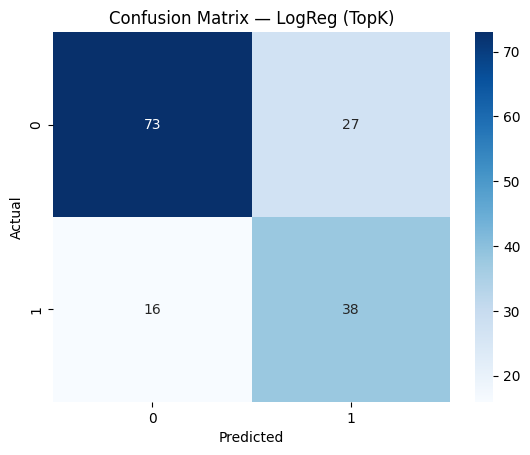

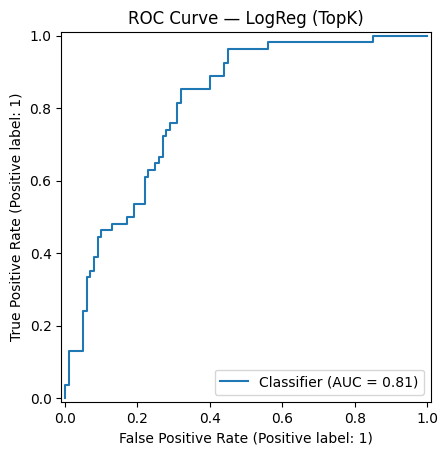

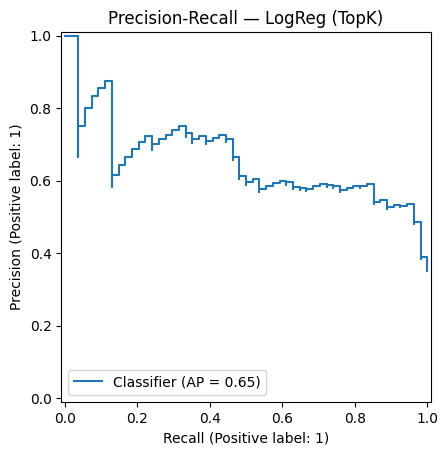

In [18]:
all_cv = pd.DataFrame(cv_scores).copy()
best_row = all_cv.sort_values('roc_auc_mean', ascending=False).iloc[0]
best_group, best_model_name = best_row['group'], best_row['model']
print('Best by CV ROC-AUC:', best_group, '|', best_model_name)

model_lookup = {}
model_lookup.update({**locals().get('base_models', {})})
model_lookup.update({**locals().get('bal_models', {})})
model_lookup.update({**locals().get('topk_models', {})})
best_pipe = model_lookup[best_model_name]

best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)
y_proba = None
try:
    y_proba = best_pipe.predict_proba(X_test)[:,1]
except Exception:
    pass

print('Classification report (TEST):')
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

if y_proba is not None:
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(f'ROC Curve — {best_model_name}')
    plt.show()
    PrecisionRecallDisplay.from_predictions(y_test, y_proba)
    plt.title(f'Precision-Recall — {best_model_name}')
    plt.show()


## 10) Discussion & Conclusion
**Advantages:**
- Leakage‑safe preprocessing embedded in pipelines.
- SMOTE inside CV and RepeatedStratifiedKFold for stability.
- Multiple model families compared under identical folds.
- Top‑k retraining provides compact models with competitive accuracy.

**Disadvantages / Limitations:**
- Small historical dataset; potential generalization gaps.
- Implausible zeros handled via imputation; measurement bias may persist.
- No probability calibration or cost‑sensitive thresholding included.
- No subgroup/fairness analysis (e.g., by age band).

**Conclusion:** Data balancing and scaling typically improve recall and balanced accuracy; Top‑k models can retain accuracy with reduced complexity. For production‑like use, consider nested CV, probability calibration, and subgroup robustness checks.
